# Tıbbi Malzeme Şirketi İçin Tavsiye Sistemi

Bu projenin amacı, bir tıbbi malzeme şirketi için satışları artırmak (incremental sales) amacıyla akıllı bir tavsiye sistemi geliştirmektir. Müşteri satın alma geçmişi ve ürün özellikleri kullanılarak; Popülarite Bazlı, İşbirlikçi Filtreleme (Matrix Factorization) ve İçerik Bazlı (Cosine Similarity) olmak üzere üç farklı yaklaşım uygulanmıştır. Bu sistem, müşterilere ilgilenebilecekleri en uygun ürünleri sunarak çapraz satışı hedeflemektedir.

## İzlenecek Adımlar
1. **Keşifçi Veri Analizi (EDA):** En popüler ürünlerin ve en çok alım yapan şirketlerin tespiti.
2. **Veri Hazırlığı (Data Prep):** Eksik verilerin temizlenmesi ve düzenlenmesi.
3. **Görselleştirme:** Satış verilerinin grafiklerle incelenmesi.
4. **Modelleme:**
   - **Popülarite Bazlı (Popularity-Based):** Yeni müşteriler için genel öneriler.
   - **Matris Faktörizasyonu (Model-Based / SVD):** Müşteri geçmişine dayalı öneriler.

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('PBL 5 recommendation data.csv', encoding='ISO-8859-1')

In [3]:
df

,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,...,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
0,797,Christy,Dill,Company0,1426018724,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF61071,0.0,NaN
1,3,John,Smith,Company1,1386089139,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF02132,NaN,NaN
2,3,John,Smith,Company1,1386089139,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2 x Extra large,Nitrile,NaN,NaN,NaN,PF00342,0.0,NaN
3,4,James,Anderson,NaN,1386780263,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF04970,NaN,NaN
4,5,Abraham,Pollak,Company3,1386861599,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF03045,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4189,3730,Nora,Fontana,NaN,1463408698,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,Plastic Rim,NaN,NaN,NaN,PF06157,3.0,NaN
4190,3732,Kennithe,Tecora,NaN,1463412756,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF08485,3.0,NaN
4191,3733,Tinna,Randall,NaN,1463413245,NaN,NaN,NaN,NaN,NaN,...,NaN,21AH Batteries,NaN,NaN,NaN,NaN,NaN,PM36,3.0,NaN
4192,3735,HALIMAH,SHAHID,NaN,1463416687,NaN,1.0,NaN,NaN,NaN,...,5.0,NaN,NaN,Aluminum,NaN,NaN,NaN,PF04829,3.0,NaN


In [4]:
df.columns.tolist()

['Customers.id',
 'Customers.fname',
 'Customers.lname',
 'Customers.company',
 'Customers.create_date',
 'Customers.status',
 'Customers.mailing',
 'Customers.reminders',
 'Customers.tax_exempt',
 'Customers.account_id',
 'Customers.sales_rep',
 'Customers.rewards',
 'Customers.profile_id',
 'Customers.last_modified',
 'Customers.customer_type',
 'Orders.id',
 'Orders.customer_id',
 'Orders.fname',
 'Orders.lname',
 'Orders.company',
 'Orders.order_number',
 'Orders.reorder_id',
 'Orders.external_source',
 'Orders.external_id',
 'Orders.currency',
 'Orders.sales_rep',
 'Orders.subtotal',
 'Orders.tax',
 'Orders.shipping',
 'Orders.coupon_id',
 'Orders.coupon_amount',
 'Orders.gift_id',
 'Orders.gift_amount',
 'Orders.fee_name',
 'Orders.fee_amount',
 'Orders.discount_name',
 'Orders.discount_amount',
 'Orders.total',
 'Orders.balance_due',
 'Orders.shipping_carrier',
 'Orders.shipping_method',
 'Orders.shipping_trans',
 'Orders.shipping_flags',
 'Orders.weight',
 'Orders.tracking',
 '

In [5]:
df.isnull().sum()

Customers.id                0
Customers.fname             0
Customers.lname             0
Customers.company        3467
Customers.create_date       0
                         ... 
Products.leg_style       4194
Products.seat_size       4032
Products.family_id        325
Products.saved_status     264
Products.freight_cost    4194
Length: 181, dtype: int64

In [6]:
# Analiz için kritik sütunları seçelim
cols_to_keep = [
    'Customers.id', 'Customers.fname', 'Customers.lname', 'Customers.company',
    'Orders.id', 'Order_Items.product_id', 'Order_Items.product_name', 
    'Order_Items.qty', 'Order_Items.price', 'Products.long_description'
]

In [7]:
data = df[cols_to_keep].copy()

In [8]:
# Sütun isimlerini daha anlaşılır hale getirelim
data.columns = ['user_id', 'fname', 'lname', 'company', 'order_id', 
                'product_id', 'product_name', 'qty', 'price', 'description']

In [9]:
data

,user_id,fname,lname,company,order_id,product_id,product_name,qty,price,description
0,797,Christy,Dill,Company0,3758,2310.0,"Basic Rollators, Green",1,57.20,"<ul><li> Classically designed, value priced</..."
1,3,John,Smith,Company1,23,177.0,"Urinary Drain Bags,0.000",4,5.00,<ul><li> Only Medline drain bags have a slide...
2,3,John,Smith,Company1,9531,1.0,"SensiCare Nitrile Exam Gloves, Blue, XX-Large",1,68.78,<ul><li> SensiCare&reg; nitrile exam gloves fe...
3,4,James,Anderson,NaN,29,983.0,Basket for 2-Button Walkers,1,19.56,<ul><li> This wire basket attaches to almost a...
4,5,Abraham,Pollak,Company3,30,991.0,Tens Units,1,36.05,<ul><li> The TENS 3000<sup>TM</sup> analog uni...
...,...,...,...,...,...,...,...,...,...,...
4189,3730,Nora,Fontana,NaN,17421,1842.0,"Medline Emesis/Barf Bags, throw up bags, Blue ...",1,14.85,<ul><li> Can be used as a sickness bag </li><...
4190,3732,Kennithe,Tecora,NaN,17425,782.0,Medline Home Bed Assist Bar,1,39.99,"<ul><li> Built to last, our Bed Assist Bar pro..."
4191,3733,Tinna,Randall,NaN,17426,2707.0,Spitfire EX Travel 4-Wheel Mobility Scooter 21...,1,1099.00,<p>For an easily transportable scooter that co...
4192,3735,HALIMAH,SHAHID,NaN,17431,993.0,"Standard Bariatric Heavy Duty Rollator, Burgun...",1,129.99,<ul><li> Reinforced design to support higher w...


In [10]:
data.isnull().sum()

user_id            0
fname              0
lname              0
company         3467
order_id           0
product_id        43
product_name       0
qty                0
price              0
description      186
dtype: int64

In [11]:
# Şirket ismi olmayanları 'Individual' (Bireysel) olarak etiketleyelim
data['company'] = data['company'].fillna('Individual')

In [12]:
# Ürün açıklaması olmayanları boş string ile dolduralım
data['description'] = data['description'].fillna('')

In [13]:
# Toplam Satış Tutarı (Total Dollar)
data['total_dollar'] = data['qty'] * data['price']

In [42]:
data

,user_id,fname,lname,company,order_id,product_id,product_name,qty,price,description,total_dollar
0,797,Christy,Dill,Company0,3758,2310.0,"Basic Rollators, Green",1,57.20,"<ul><li> Classically designed, value priced</...",57.20
1,3,John,Smith,Company1,23,177.0,"Urinary Drain Bags,0.000",4,5.00,<ul><li> Only Medline drain bags have a slide...,20.00
2,3,John,Smith,Company1,9531,1.0,"SensiCare Nitrile Exam Gloves, Blue, XX-Large",1,68.78,<ul><li> SensiCare&reg; nitrile exam gloves fe...,68.78
3,4,James,Anderson,Individual,29,983.0,Basket for 2-Button Walkers,1,19.56,<ul><li> This wire basket attaches to almost a...,19.56
4,5,Abraham,Pollak,Company3,30,991.0,Tens Units,1,36.05,<ul><li> The TENS 3000<sup>TM</sup> analog uni...,36.05
...,...,...,...,...,...,...,...,...,...,...,...
4189,3730,Nora,Fontana,Individual,17421,1842.0,"Medline Emesis/Barf Bags, throw up bags, Blue ...",1,14.85,<ul><li> Can be used as a sickness bag </li><...,14.85
4190,3732,Kennithe,Tecora,Individual,17425,782.0,Medline Home Bed Assist Bar,1,39.99,"<ul><li> Built to last, our Bed Assist Bar pro...",39.99
4191,3733,Tinna,Randall,Individual,17426,2707.0,Spitfire EX Travel 4-Wheel Mobility Scooter 21...,1,1099.00,<p>For an easily transportable scooter that co...,1099.00
4192,3735,HALIMAH,SHAHID,Individual,17431,993.0,"Standard Bariatric Heavy Duty Rollator, Burgun...",1,129.99,<ul><li> Reinforced design to support higher w...,129.99


In [45]:
# HTML temizleme fonksiyonu
def clean_html_beautifulsoup(text):
    if isinstance(text, str):
        return BeautifulSoup(text, "html.parser").get_text()
    return text

data['description'] = data['description'].apply(clean_html_beautifulsoup)

In [46]:
data

,user_id,fname,lname,company,order_id,product_id,product_name,qty,price,description,total_dollar
0,797,Christy,Dill,Company0,3758,2310.0,"Basic Rollators, Green",1,57.20,"Classically designed, value priced Construc...",57.20
1,3,John,Smith,Company1,23,177.0,"Urinary Drain Bags,0.000",4,5.00,Only Medline drain bags have a slide tap for...,20.00
2,3,John,Smith,Company1,9531,1.0,"SensiCare Nitrile Exam Gloves, Blue, XX-Large",1,68.78,SensiCare® nitrile exam gloves feature depend...,68.78
3,4,James,Anderson,Individual,29,983.0,Basket for 2-Button Walkers,1,19.56,This wire basket attaches to almost any walke...,19.56
4,5,Abraham,Pollak,Company3,30,991.0,Tens Units,1,36.05,The TENS 3000TM analog unit uses a microproce...,36.05
...,...,...,...,...,...,...,...,...,...,...,...
4189,3730,Nora,Fontana,Individual,17421,1842.0,"Medline Emesis/Barf Bags, throw up bags, Blue ...",1,14.85,Can be used as a sickness bag Tie bag off a...,14.85
4190,3732,Kennithe,Tecora,Individual,17425,782.0,Medline Home Bed Assist Bar,1,39.99,"Built to last, our Bed Assist Bar provides he...",39.99
4191,3733,Tinna,Randall,Individual,17426,2707.0,Spitfire EX Travel 4-Wheel Mobility Scooter 21...,1,1099.00,For an easily transportable scooter that combi...,1099.00
4192,3735,HALIMAH,SHAHID,Individual,17431,993.0,"Standard Bariatric Heavy Duty Rollator, Burgun...",1,129.99,Reinforced design to support higher weight ca...,129.99


In [47]:
data.isnull().sum()

user_id          0
fname            0
lname            0
company          0
order_id         0
product_id      43
product_name     0
qty              0
price            0
description      0
total_dollar     0
dtype: int64

In [48]:
print(data[data['product_id'].isnull()]['product_name'].unique())

['Drive medical excersize paddler item #RTL10273 '
 'Drive Medical item # RTL10273'
 'Drive Medical Folding Exercise Peddler W/ Electronic Display RTL10273 '
 'Drive medical excersize peddler RTL10273'
 'Drive Medical folding Exercise peddler RTL10273'
 'Drive Medical Excercise Peddler RTL10273' 'G98006. Tub Grab Bars 3/Case'
 'ORT33100LM' 'ORT29100XL' 'WCATR012 ' 'SKU:WCA806901' '12112-3' '12124-3'
 'MPHSAFETY21Z' 'ORT30310P' 'NONSH100CZ\t' 'STDS3J24SF' 'g222-0913'
 'ORT213003XL' 'Drive Medical FWSFBLK' 'ROYMJP250'
 'PKUFP360 Attends Supers-orb under-pads ' 'Drive Medical 9505w1026110'
 'Contour Products CPAPmax Pillow with Zippered Cover'
 'Adjustable Height ArmRest AK5ADJARMKIT ' 'WCA808990'
 'MMM15300Z 24 Eaches' 'mmm15330zz '
 'Drive Medical 11838-1 {Custom Item} ' 'Knob for translator WCATR007'
 '6291hda Universal wheels part' 'MDTCS4M80 Fitted Sheets'
 'MDTFS4M04N Flat Sheets' 'MDTPC4M34 Pillow Case' 'SPDELR-TF'
 'G81030KEM\t' 'G81060KEM' 'TruTemp'
 'Sure-Grip Terrycloth Slipper

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4194 entries, 0 to 4193
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       4194 non-null   int64  
 1   fname         4194 non-null   object 
 2   lname         4194 non-null   object 
 3   company       4194 non-null   object 
 4   order_id      4194 non-null   int64  
 5   product_id    4151 non-null   float64
 6   product_name  4194 non-null   object 
 7   qty           4194 non-null   int64  
 8   price         4194 non-null   float64
 9   description   4194 non-null   object 
 10  total_dollar  4194 non-null   float64
dtypes: float64(3), int64(3), object(5)
memory usage: 360.6+ KB


In [49]:
# product_id si boş olanları çıkar
data = data.dropna(subset=['product_id'])
# product_id float formatında kaldıysa (örn: 123.0), integer'a çevirip düzeltelim
data['product_id'] = data['product_id'].astype(int)

In [50]:
data.isnull().sum()

user_id         0
fname           0
lname           0
company         0
order_id        0
product_id      0
product_name    0
qty             0
price           0
description     0
total_dollar    0
dtype: int64

In [51]:
# 1. En çok satan ürün (Miktar / Volume bazında)
most_popular_vol = data.groupby('product_name')['qty'].sum().sort_values(ascending=False)

In [52]:
most_popular_vol

product_name
Disposable Emergency Blanket, Gray, Not Applicable                          305
2-Ply Tissue/Poly Professional Towels, White, Not Applicable                220
Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size    164
Sanitary Pads with Adhesive & Wings                                         133
Corrugated Aerosol Tubing                                                   110
                                                                           ... 
Pediatric Folding Walkers, Green, 5"                                          1
Disposable Tissue / Poly / Tissue Exam Capes, Blue, 30" W X 21"L              1
Pediatric Folding Walkers, Pediatric                                          1
Pediatric Folding Walkers, Red, Pediatric                                     1
sEMG - single use uni-gel electrodes only, case of 100                        1
Name: qty, Length: 1778, dtype: int64

In [53]:
# 2. En çok ciro getiren ürün (Dollar Amount bazında)
most_popular_val = data.groupby('product_name')['total_dollar'].sum().sort_values(ascending=False)

In [54]:
most_popular_val

product_name
Disposable Emergency Blanket, Gray, Not Applicable                                                                                    10556.05
Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size                                                               8984.40
Medline Deluxe Aluminum Transport Chair With Hand Brakes, Red, Wheels Front 8" Back 12", Leightweight Weighs 23 Lbs, Cap. 300 Lbs.     5940.54
Sanitary Pads with Adhesive & Wings                                                                                                    5628.56
2-Ply Tissue/Poly Professional Towels, White, Not Applicable                                                                           5559.40
                                                                                                                                        ...   
OR Sterile Specimen Containers, 120.0 ML                                                                                         

In [55]:
# 3. En çok satın alım yapan şirket (Individual hariç)
company_sales = data[data['company'] != 'Individual'].groupby('company')['total_dollar'].sum().sort_values(ascending=False)

In [56]:
company_sales

company
Company59     13186.41
Company343     5628.56
Company145     2696.38
Company17      2653.30
Company207     2375.59
                ...   
Company183        9.66
Company392        8.91
Company375        6.98
Company102        6.40
Company155        3.64
Name: total_dollar, Length: 423, dtype: float64

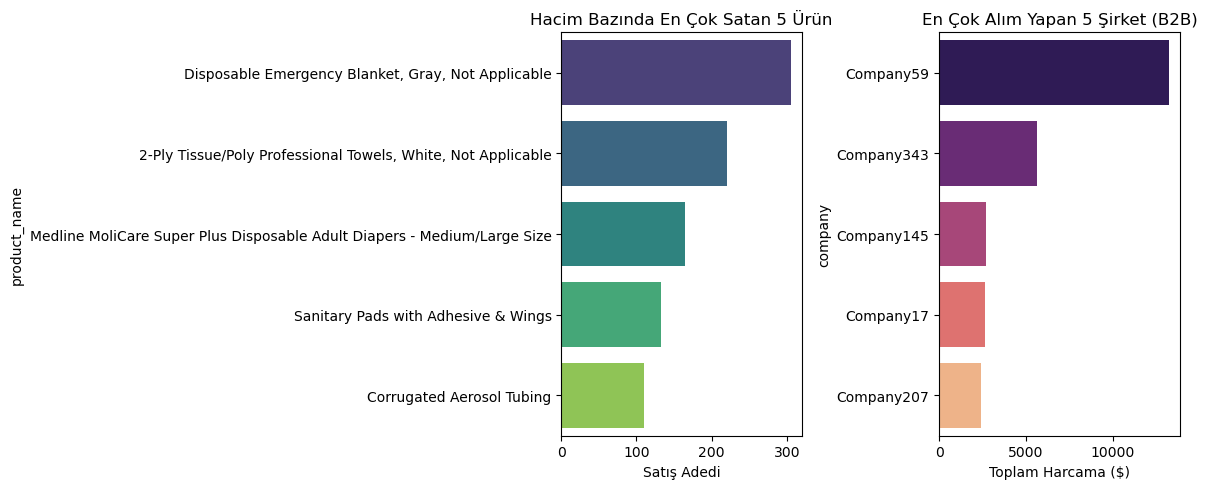

In [57]:
plt.figure(figsize=(12, 5))

# Grafik 1: En Çok Satan 5 Ürün
plt.subplot(1, 2, 1)
top_products = most_popular_vol.head(5)
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Hacim Bazında En Çok Satan 5 Ürün')
plt.xlabel('Satış Adedi')

# Grafik 2: En Çok Harcama Yapan 5 Şirket
plt.subplot(1, 2, 2)
top_companies = company_sales.head(5)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='magma')
plt.title('En Çok Alım Yapan 5 Şirket (B2B)')
plt.xlabel('Toplam Harcama ($)')

plt.tight_layout()
plt.show()

### Popülarite Bazlı Tavsiye Sistemi

In [58]:
# En popüler n ürünü döndüren fonksiyon
def get_popularity_recommendations(n=5):
    # Hem miktar hem ciro ortalamasını alarak skorlayabiliriz, burada miktarı baz alıyoruz
    popular = data.groupby('product_name')['qty'].sum().sort_values(ascending=False).head(n)
    return popular.index.tolist()

In [59]:
get_popularity_recommendations()

['Disposable Emergency Blanket, Gray, Not Applicable',
 '2-Ply Tissue/Poly Professional Towels, White, Not Applicable',
 'Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size',
 'Sanitary Pads with Adhesive & Wings',
 'Corrugated Aerosol Tubing']

### Matris Faktörizasyonu (Collaborative Filtering)

In [139]:
user_item_matrix = data.pivot_table(index='user_id', columns='product_id', values='qty', aggfunc='sum').fillna(0)

In [140]:
user_item_matrix.shape

(3026, 1753)

In [141]:
# Miktar verisini normalize etme (Log Transformation)
# Bu işlem, 1000 adet alınan ucuz ürünün, 1 adet alınan pahalı ürünü ezmesini engeller.
user_item_matrix = user_item_matrix.map(lambda x: np.log1p(x))

In [142]:
# SVD (Singular Value Decomposition) Uygulama
# Veri seyrek (sparse) olduğu için boyut indirgeme yapıyoruz
# n_components = 20 Bileşen sayısı
svd = TruncatedSVD(n_components=20, random_state=42)
matrix_decomposed = svd.fit_transform(user_item_matrix)

In [143]:
# Korelasyon Matrisi (Hangi kullanıcılar birbirine benziyor?)
corr_matrix = np.corrcoef(matrix_decomposed)

In [144]:
user_item_matrix.shape

(3026, 1753)

In [145]:
# Öneri yaparken ID'den İsme Çevirme
product_id_to_name = data.set_index('product_id')['product_name'].to_dict()

In [146]:
# Öneri Fonksiyonu
def recommend_with_svd(user_id, n=5, filter_bought=False):
    # 1. Kullanıcı Kontrolü
    if user_id not in user_item_matrix.index:
        return ["Kullanıcı Geçmişi Yok - Popüler Ürünler:"] + get_popularity_recommendations(n)
    
    # 2. Kullanıcının ID'sini ve Matris İndeksini al
    user_idx = user_item_matrix.index.get_loc(user_id)
    
    # 3. SVD ile Puan Tahmini Yapma (İşte SVD'nin büyüsü burası!)
    # Kullanıcının gizli özellik vektörü (latent features)
    user_latent_vector = matrix_decomposed[user_idx].reshape(1, -1)
    
    # Tüm ürünler için tahmin skorlarını hesapla (Dot Product)
    # (1, 20) x (20, ÜrünSayısı) -> (1, ÜrünSayısı)
    predicted_scores = np.dot(user_latent_vector, svd.components_).flatten()
    
    # 4. Kullanıcının zaten aldığı ürünleri filtrele
    # Orijinal matriste değeri 0'dan büyük olanlar (zaten alınmış)
    user_original_ratings = user_item_matrix.iloc[user_idx].values
    
    # filter_bought true olarak gonderilirse zaten alınan ürünlerin skorunu -1 yap ki önerilmesin
    # Sadece yeni ürün keşfetmesini istiyorsak filtreleyelim
    if filter_bought:
        user_original_ratings = user_item_matrix.iloc[user_idx].values
        predicted_scores[user_original_ratings > 0] = -float('inf') # -1 yerine -sonsuz daha güvenlidir
    
    # 5. En yüksek skorlu n ürünü getir
    # argsort küçükten büyüğe sıralar, biz ters çevirip (-1 ile çarpıp) başı alıyoruz
    top_indices = predicted_scores.argsort()[::-1][:n]
    
    # 6. Ürün ID'lerini İsimlere Çevir
    all_product_ids = user_item_matrix.columns
    recommended_products = []
    
    for idx in top_indices:
        prod_id = all_product_ids[idx]
        prod_name = product_id_to_name.get(prod_id, f"Ürün {prod_id}")
        recommended_products.append(prod_name)
        
    return recommended_products

In [147]:
# User 3 İçin SVD (User-Based) Önerileri
# Sadece yeni ürün keşfetmesini istiyorsak filter_bought True gonderilmeli
recommend_with_svd(3)

['2-Ply Tissue/Poly Professional Towels, White, Not Applicable',
 'Fresh Wave Continuous Release Gel, 8.000 OZ',
 'Corrugated Aerosol Tubing',
 'Plus-Sized Bariatric Blood Pressure Cuff',
 'Medline Elite Automatic Digital Blood Pressure Monitor']

### İçerik Bazlı Tavsiye (Content-Based)

Ürün açıklamalarının benzerliğine göre öneri yapma - NLP Yaklaşımı

In [148]:
# Sadece tekil ürünleri ve açıklamalarını alalım
products_df = data[['product_name', 'description']].drop_duplicates(subset='product_name').reset_index(drop=True)

In [149]:
# İngilizce stop words'e ek olarak medikal/ticari terimleri de atalım
custom_stop_words = list(TfidfVectorizer(stop_words='english').get_stop_words()) + ['medline', 'size', 'pack', 'case', 'latex', 'sterile']

In [150]:
products_df

,product_name,description
0,"Basic Rollators, Green","Classically designed, value priced Construc..."
1,"Urinary Drain Bags,0.000",Only Medline drain bags have a slide tap for...
2,"SensiCare Nitrile Exam Gloves, Blue, XX-Large",SensiCare® nitrile exam gloves feature depend...
3,Basket for 2-Button Walkers,This wire basket attaches to almost any walke...
4,Tens Units,The TENS 3000TM analog unit uses a microproce...
...,...,...
1773,"Commode Seat & Lid, ""Seat And Lid Only""",Seat and Lid commode for MDS89664.
1774,Relief Pak&reg; Moist Heating Pad For Neck Pa...,Relief Pak® moist heat packs and covers are a ...
1775,"Relief Pak&reg; Moist Heat Pack - Spine - 10"" ...",Relief Pak® moist heat packs and covers are a ...
1776,Spitfire EX Travel 4-Wheel Mobility Scooter 21...,For an easily transportable scooter that combi...


In [151]:
custom_stop_words

['back',
 'or',
 'never',
 'bottom',
 'whereby',
 'alone',
 'system',
 'being',
 'up',
 'fill',
 'sincere',
 'everything',
 'therein',
 'otherwise',
 'indeed',
 'only',
 'into',
 'anyhow',
 'until',
 'rather',
 'although',
 'still',
 'she',
 'thereafter',
 'yourselves',
 'across',
 'anyone',
 'becomes',
 'made',
 'upon',
 'seems',
 'five',
 'two',
 'ten',
 'hence',
 'once',
 'detail',
 'thus',
 'top',
 'part',
 'further',
 'while',
 'against',
 'next',
 'for',
 'three',
 'around',
 'ours',
 'during',
 'any',
 'nothing',
 'less',
 'after',
 'beyond',
 'first',
 'hers',
 'either',
 'get',
 'own',
 'third',
 'in',
 'few',
 'seemed',
 'be',
 'already',
 'could',
 'eleven',
 'i',
 'describe',
 'twenty',
 'his',
 'six',
 'co',
 'which',
 'a',
 'interest',
 'too',
 'besides',
 'everywhere',
 'without',
 'am',
 'hasnt',
 'behind',
 'will',
 'several',
 'whatever',
 'by',
 'former',
 'something',
 'some',
 'namely',
 'per',
 'sometime',
 'what',
 'that',
 'such',
 'before',
 'least',
 'else',
 

In [152]:
# Ürün ID'sini index yaparak veriyi hazırla (Duplicate ID'leri at)
products_content = data[['product_id', 'product_name', 'description']].drop_duplicates(subset='product_id').set_index('product_id')

In [153]:
# TF-IDF Vektörleştirme (Metni sayılara dökme)
tfidf = TfidfVectorizer(stop_words=custom_stop_words)
tfidf_matrix = tfidf.fit_transform(products_content['description'])

In [154]:
# Cosine Similarity (Kosinüs Benzerliği) Hesaplama
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [155]:
# İndeks serisi oluşturma
id_to_index = pd.Series(range(len(products_content)), index=products_content.index)

In [156]:
def recommend_similar_products_by_id(target_product_id, n=5):
    if target_product_id not in id_to_index:
        return ["Ürün bulunamadı."]
    
    # Ürünün matris indeksini bul
    idx = id_to_index[target_product_id]
    
    # Benzerlik skorlarını al
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Kendisi (0. indeks) hariç ilk n taneyi al
    sim_scores = sim_scores[1:n+1]
    product_indices = [i[0] for i in sim_scores]
    
    # İsimleri getir
    return products_content['product_name'].iloc[product_indices].tolist()

In [157]:
popular_product_id = most_popular_vol.index[0]

In [158]:
popular_product_id

'Disposable Emergency Blanket, Gray, Not Applicable'

In [159]:
# 2310 Basic Rollators ID'si için benzer ürünler
recommend_similar_products_by_id(2310)

['Basic Steel Rollators, Blue',
 'Basic Steel Rollators, Red',
 'Basic Steel Rollators, Blue',
 'Basic Steel Rollators For Adults, With Seat, Green, 8" Wheels, Foldable',
 'Basic Steel Rollators, Burgundy, 6"']

In [160]:
# HYBRID ENGINE
# Bu fonksiyon senaryoya göre en uygun algoritmayı seçer.
# 1. Ürün sayfasındaysa -> İçerik bazlı (Benzer ürünler)
# 2. Kullanıcı giriş yapmışsa ve geçmişi varsa -> SVD (Kişiye özel)
# 3. Kullanıcı yeni veya giriş yapmamışsa -> Popülarite
def get_recommendations(user_id=None, product_id=None, n=5):
    # Senaryo 1: Kullanıcı bir ürüne bakıyor (Ürün Detay Sayfası)
    if product_id is not None:
        print(f"--- Ürün ({product_id}) Benzerleri Getiriliyor (Content-Based) ---")
        return recommend_similar_products_by_id(product_id, n)
    
    # Senaryo 2: Kullanıcı Anasayfada (Kişiye Özel Öneri)
    if user_id is not None:
        # Kullanıcı verimizde var mı kontrolü zaten svd fonksiyonunda yapılıyor
        print(f"--- Kullanıcı ({user_id}) İçin Öneriler (Collaborative/SVD) ---")
        return recommend_with_svd(user_id, n, filter_bought=False) # Tıbbi malzeme olduğu için tekrar alım açık
        
    # Senaryo 3: Hiçbir bilgi yok (Cold Start)
    print("--- Genel Popüler Ürünler (Best Sellers) ---")
    return get_popularity_recommendations(n)

In [161]:
print("SENARYO 1 (Ürün):", get_recommendations(product_id=2310))

--- Ürün (2310) Benzerleri Getiriliyor (Content-Based) ---
SENARYO 1 (Ürün): ['Basic Steel Rollators, Blue', 'Basic Steel Rollators, Red', 'Basic Steel Rollators, Blue', 'Basic Steel Rollators For Adults, With Seat, Green, 8" Wheels, Foldable', 'Basic Steel Rollators, Burgundy, 6"']


In [162]:
print("\nSENARYO 2 (User):", get_recommendations(user_id=3))

--- Kullanıcı (3) İçin Öneriler (Collaborative/SVD) ---

SENARYO 2 (User): ['2-Ply Tissue/Poly Professional Towels, White, Not Applicable', 'Fresh Wave Continuous Release Gel, 8.000 OZ', 'Corrugated Aerosol Tubing', 'Plus-Sized Bariatric Blood Pressure Cuff', 'Medline Elite Automatic Digital Blood Pressure Monitor']


In [163]:
print("\nSENARYO 3 (Anonim):", get_recommendations())

--- Genel Popüler Ürünler (Best Sellers) ---

SENARYO 3 (Anonim): ['Disposable Emergency Blanket, Gray, Not Applicable', '2-Ply Tissue/Poly Professional Towels, White, Not Applicable', 'Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size', 'Sanitary Pads with Adhesive & Wings', 'Corrugated Aerosol Tubing']


Geliştirdiğiniz bu Hibrit Tavsiye Sistemi;
- Ürünlerin metin açıklamalarını anlayarak alternatif ürün sunabiliyor.
- Müşterilerin satın alma alışkanlıklarını çözerek onlara gizli ihtiyaçlarını (almayı unuttukları ürünleri) hatırlatıyor.
- Yeni gelen müşteriyi boş karşılamayıp en popüler ürünlerle ilgisini çekiyor.

In [164]:
# 1. Kaydedilecek tüm parçaları bir sözlükte (dictionary) toplayalım
system_data = {
    'svd_model': svd,
    'user_item_matrix': user_item_matrix,
    'matrix_decomposed': matrix_decomposed,
    'tfidf_vectorizer': tfidf,
    'cosine_sim': cosine_sim,
    'product_id_to_name': product_id_to_name,
    'products_content': products_content,
    'id_to_index': id_to_index,
    'popular_products': get_popularity_recommendations(10) # İlk 10 popüleri list olarak saklayalım
}

In [167]:
# 2. Dosyayı diske kaydedelim (Export)
joblib.dump(system_data, 'medical_recommender.pkl')

['medical_recommender.pkl']